# Tech Challenge — Fase 4
## Etapa 5: Escalabilidade e Monitoramento da API LSTM

Este notebook cobre o **ponto 5** do desafio: configurar monitoramento para a API
de previsão, acompanhando **tempo de resposta**, **taxa de erros**, **volume de
requisições**, **latência da inferência** e **utilização de CPU e memória**.

Também avaliamos a escalabilidade com testes de carga em diferentes níveis de
concorrência e disponibilizamos métricas no padrão **Prometheus**, prontas para
visualização no **Grafana**.

**Pré-requisito:** ter executado as etapas anteriores, que geraram:

- `models/lstm_final.onnx` (gerado por `python scripts/export_onnx.py`)
- `artifacts/ret_scaler.pkl`
- `artifacts/inference_meta.pkl`
- `artifacts/<SIMBOLO>_clean.csv`

A inferência aqui usa **ONNX Runtime**, o mesmo runtime da API de produção em
`app/`. Medir sobre o TensorFlow produziria números de latência e memória que não
correspondem ao que roda em produção.

Fluxo:

1. Carregar o modelo e os artefatos de inferência
2. Instrumentar a API FastAPI com métricas Prometheus
3. Monitorar latência, erros, CPU e memória
4. Registrar feedback para acompanhar erro preditivo em produção
5. Executar testes de carga concorrentes
6. Avaliar SLOs de disponibilidade e desempenho
7. Gerar arquivos de configuração para Prometheus e Grafana


## 0. Instalação e imports

Descomente a linha de instalação caso as bibliotecas ainda não estejam
disponíveis no ambiente.


In [1]:
# !pip install onnxruntime fastapi pydantic httpx uvicorn joblib prometheus-client psutil pandas numpy matplotlib

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import asyncio
import json
import threading
from pathlib import Path
from time import perf_counter
from typing import List, Optional

import httpx
import joblib
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import psutil

from fastapi import FastAPI, HTTPException, Request
from fastapi.testclient import TestClient
from IPython.display import display
from prometheus_client import (
    CollectorRegistry,
    Counter,
    Gauge,
    Histogram,
    make_asgi_app,
)
from pydantic import BaseModel, Field

print("ONNX Runtime:", ort.__version__)
print("Setup de monitoramento OK")


ONNX Runtime: 1.28.0
Setup de monitoramento OK


/home/doglas/Documents/FIAP/fiap-tech-challenge-4/.venv/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## 1. Caminhos e validação dos artefatos

A API monitorada usa exatamente os mesmos artefatos produzidos pelo notebook 02.
A validação abaixo interrompe a execução com uma mensagem clara caso alguma etapa
anterior ainda não tenha sido executada.


In [2]:
MODEL_PATH  = "models/lstm_final.onnx"
SCALER_PATH = "artifacts/ret_scaler.pkl"
META_PATH   = "artifacts/inference_meta.pkl"

arquivos_obrigatorios = [MODEL_PATH, SCALER_PATH, META_PATH]
ausentes = [arquivo for arquivo in arquivos_obrigatorios if not os.path.exists(arquivo)]

if ausentes:
    raise FileNotFoundError(
        "Artefatos não encontrados: "
        + ", ".join(ausentes)
        + ". Execute os notebooks 01 e 02 e depois scripts/export_onnx.py."
    )

print("Artefatos necessários encontrados.")


Artefatos necessários encontrados.


## 2. Inferência canônica

A classe abaixo mantém a mesma regra de `app/predictor.py`:

1. recebe preços históricos;
2. transforma os preços em log-retornos;
3. aplica o `StandardScaler`;
4. executa a LSTM exportada para ONNX;
5. reconstrói o preço com `P̂ = P_anterior × exp(retorno_previsto)`.

A sessão ONNX é criada **uma única vez**, evitando o custo de recarregamento a
cada requisição. A entrada é convertida para `float32`, o tipo do grafo
exportado.


In [3]:
class Predictor:
    def __init__(
        self,
        model_path: str = MODEL_PATH,
        scaler_path: str = SCALER_PATH,
        meta_path: str = META_PATH,
    ):
        self.session = ort.InferenceSession(
            model_path,
            providers=["CPUExecutionProvider"],
        )
        self.input_name = self.session.get_inputs()[0].name
        self.scaler = joblib.load(scaler_path)
        self.meta = joblib.load(meta_path)
        self.window = int(self.meta["window_size"])
        self.symbol = self.meta.get("symbol")

    @property
    def min_prices(self) -> int:
        return self.window + 1

    def predict(self, prices, horizon: int = 1) -> List[float]:
        prices = np.asarray(prices, dtype=float)

        if prices.ndim != 1:
            raise ValueError("'prices' deve ser uma lista 1D de preços.")
        if len(prices) < self.min_prices:
            raise ValueError(
                f"São necessários pelo menos {self.min_prices} preços "
                f"(janela={self.window}); recebidos {len(prices)}."
            )
        if np.any(~np.isfinite(prices)):
            raise ValueError("Todos os preços devem ser números finitos.")
        if np.any(prices <= 0):
            raise ValueError("Todos os preços devem ser positivos.")
        if not 1 <= int(horizon) <= 30:
            raise ValueError("'horizon' deve estar entre 1 e 30.")

        recent = prices[-self.min_prices:]
        log_returns = np.diff(np.log(recent))
        window_scaled = self.scaler.transform(
            log_returns.reshape(-1, 1)
        ).flatten()

        predictions = []
        last_price = float(recent[-1])

        for _ in range(int(horizon)):
            x = window_scaled.reshape(1, self.window, 1).astype(np.float32)

            saida = self.session.run(None, {self.input_name: x})
            predicted_scaled_return = float(
                np.asarray(saida[0]).reshape(-1)[0]
            )

            predicted_return = float(
                self.scaler.inverse_transform(
                    [[predicted_scaled_return]]
                )[0, 0]
            )
            next_price = float(last_price * np.exp(predicted_return))

            predictions.append(next_price)
            window_scaled = np.append(
                window_scaled[1:],
                predicted_scaled_return,
            )
            last_price = next_price

        return predictions


predictor = Predictor()
print(
    f"Modelo carregado | símbolo={predictor.symbol} "
    f"| janela={predictor.window} "
    f"| mínimo de preços={predictor.min_prices}"
)


Modelo carregado | símbolo=AAPL | janela=60 | mínimo de preços=61


## 3. Métricas Prometheus

Usamos um `CollectorRegistry` próprio para evitar duplicação de métricas quando
as células são executadas novamente no Jupyter.

As métricas foram divididas em três grupos:

- **API:** requisições, erros, requisições em andamento e latência HTTP;
- **modelo:** tempo de inferência, quantidade de previsões e erro recebido por feedback;
- **recursos:** CPU, memória do sistema e memória do processo da API.


In [4]:
REGISTRY = CollectorRegistry()

HTTP_REQUESTS_TOTAL = Counter(
    "lstm_api_http_requests_total",
    "Quantidade total de requisições HTTP.",
    ["method", "path", "status"],
    registry=REGISTRY,
)

HTTP_REQUEST_DURATION = Histogram(
    "lstm_api_http_request_duration_seconds",
    "Duração das requisições HTTP em segundos.",
    ["method", "path"],
    buckets=(0.005, 0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1, 2, 5),
    registry=REGISTRY,
)

HTTP_REQUESTS_IN_PROGRESS = Gauge(
    "lstm_api_http_requests_in_progress",
    "Quantidade de requisições atualmente em processamento.",
    ["method", "path"],
    registry=REGISTRY,
)

MODEL_INFERENCE_DURATION = Histogram(
    "lstm_model_inference_duration_seconds",
    "Tempo gasto somente na inferência do modelo.",
    buckets=(0.001, 0.005, 0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1, 2, 5),
    registry=REGISTRY,
)

MODEL_PREDICTIONS_TOTAL = Counter(
    "lstm_model_predictions_total",
    "Quantidade total de previsões produzidas.",
    ["horizon"],
    registry=REGISTRY,
)

MODEL_LAST_PREDICTED_PRICE = Gauge(
    "lstm_model_last_predicted_price",
    "Último preço previsto pelo modelo.",
    registry=REGISTRY,
)

MODEL_LAST_RELATIVE_CHANGE_PERCENT = Gauge(
    "lstm_model_last_relative_change_percent",
    "Variação percentual da última previsão em relação ao último preço informado.",
    registry=REGISTRY,
)

MODEL_FEEDBACK_TOTAL = Counter(
    "lstm_model_feedback_total",
    "Quantidade de observações reais enviadas para avaliação online.",
    registry=REGISTRY,
)

MODEL_ABSOLUTE_ERROR = Histogram(
    "lstm_model_absolute_error",
    "Erro absoluto entre preço previsto e preço observado.",
    buckets=(0.1, 0.5, 1, 2, 5, 10, 20, 50, 100),
    registry=REGISTRY,
)

MODEL_ABSOLUTE_PERCENTAGE_ERROR = Histogram(
    "lstm_model_absolute_percentage_error",
    "Erro percentual absoluto entre previsão e valor observado.",
    buckets=(0.1, 0.25, 0.5, 1, 2, 5, 10, 20, 50),
    registry=REGISTRY,
)

MODEL_LAST_ABSOLUTE_ERROR = Gauge(
    "lstm_model_last_absolute_error",
    "Último erro absoluto registrado.",
    registry=REGISTRY,
)

MODEL_LAST_ABSOLUTE_PERCENTAGE_ERROR = Gauge(
    "lstm_model_last_absolute_percentage_error",
    "Último erro percentual absoluto registrado.",
    registry=REGISTRY,
)

SYSTEM_CPU_PERCENT = Gauge(
    "lstm_api_system_cpu_percent",
    "Utilização de CPU do sistema em percentual.",
    registry=REGISTRY,
)

SYSTEM_MEMORY_PERCENT = Gauge(
    "lstm_api_system_memory_percent",
    "Utilização de memória do sistema em percentual.",
    registry=REGISTRY,
)

PROCESS_CPU_PERCENT = Gauge(
    "lstm_api_process_cpu_percent",
    "Utilização de CPU do processo da API em percentual.",
    registry=REGISTRY,
)

PROCESS_RSS_BYTES = Gauge(
    "lstm_api_process_resident_memory_bytes",
    "Memória residente utilizada pelo processo da API em bytes.",
    registry=REGISTRY,
)

PROCESS = psutil.Process(os.getpid())

# Inicializa as medições de CPU para que as leituras seguintes sejam úteis.
psutil.cpu_percent(interval=None)
PROCESS.cpu_percent(interval=None)

print("Métricas Prometheus registradas.")


Métricas Prometheus registradas.


## 4. API FastAPI instrumentada

O middleware mede todas as chamadas da API, exceto o próprio endpoint de
métricas. O endpoint `/feedback` permite registrar o preço real quando ele se
tornar conhecido, possibilitando acompanhar o erro preditivo em produção.

Endpoints:

- `GET /health` — saúde da API e resumo de recursos;
- `GET /ready` — confirma que o modelo está carregado;
- `POST /predict` — realiza a previsão;
- `POST /feedback` — registra previsão versus valor real;
- `GET /metrics/` — expõe métricas no formato Prometheus.


In [5]:
class PredictRequest(BaseModel):
    prices: List[float] = Field(
        ...,
        description="Fechamentos do mais antigo ao mais recente.",
    )
    horizon: int = Field(
        1,
        ge=1,
        le=30,
        description="Quantidade de dias previstos de forma recursiva.",
    )
    symbol: Optional[str] = Field(
        None,
        description=(
            "Ação a que os preços se referem. Apenas rotula a "
            "resposta: o modelo carregado é usado de qualquer forma."
        ),
    )


class PredictResponse(BaseModel):
    # 'symbol' é a ação que a requisição diz representar;
    # 'model_trained_on' é a ação em que o modelo foi treinado.
    symbol: Optional[str] = None
    model_trained_on: Optional[str] = None
    last_price: float
    horizon: int
    predictions: List[float]


class FeedbackRequest(BaseModel):
    predicted_price: float = Field(..., gt=0)
    actual_price: float = Field(..., gt=0)


class FeedbackResponse(BaseModel):
    absolute_error: float
    absolute_percentage_error: float


def update_resource_metrics() -> dict:
    system_cpu = float(psutil.cpu_percent(interval=None))
    system_memory = float(psutil.virtual_memory().percent)
    process_cpu = float(PROCESS.cpu_percent(interval=None))
    process_rss = int(PROCESS.memory_info().rss)

    SYSTEM_CPU_PERCENT.set(system_cpu)
    SYSTEM_MEMORY_PERCENT.set(system_memory)
    PROCESS_CPU_PERCENT.set(process_cpu)
    PROCESS_RSS_BYTES.set(process_rss)

    return {
        "system_cpu_percent": system_cpu,
        "system_memory_percent": system_memory,
        "process_cpu_percent": process_cpu,
        "process_rss_mb": process_rss / (1024 ** 2),
    }


app = FastAPI(
    title="Tech Challenge Fase 4 — API LSTM Monitorada",
    version="2.0.0",
)


@app.middleware("http")
async def prometheus_middleware(request: Request, call_next):
    path = request.url.path
    method = request.method

    # Evita que o scraping do Prometheus distorça as métricas da API.
    if path.startswith("/metrics"):
        return await call_next(request)

    HTTP_REQUESTS_IN_PROGRESS.labels(method=method, path=path).inc()
    started_at = perf_counter()
    status_code = 500

    try:
        response = await call_next(request)
        status_code = response.status_code
        return response
    finally:
        elapsed = perf_counter() - started_at

        HTTP_REQUESTS_IN_PROGRESS.labels(
            method=method,
            path=path,
        ).dec()

        HTTP_REQUESTS_TOTAL.labels(
            method=method,
            path=path,
            status=str(status_code),
        ).inc()

        HTTP_REQUEST_DURATION.labels(
            method=method,
            path=path,
        ).observe(elapsed)

        update_resource_metrics()


@app.get("/health")
def health():
    resources = update_resource_metrics()
    return {
        "status": "ok",
        "model_trained_on": predictor.symbol,
        "window_size": predictor.window,
        "min_prices": predictor.min_prices,
        "resources": resources,
    }


@app.get("/ready")
def ready():
    return {
        "status": "ready",
        "model_loaded": predictor.session is not None,
        "scaler_loaded": predictor.scaler is not None,
        "model_trained_on": predictor.symbol,
    }


@app.post("/predict", response_model=PredictResponse)
def predict(req: PredictRequest):
    started_at = perf_counter()

    try:
        predictions = predictor.predict(
            req.prices,
            horizon=req.horizon,
        )
    except ValueError as exc:
        raise HTTPException(status_code=422, detail=str(exc)) from exc
    finally:
        MODEL_INFERENCE_DURATION.observe(
            perf_counter() - started_at
        )

    last_price = float(req.prices[-1])
    first_prediction = float(predictions[0])
    relative_change = (
        (first_prediction - last_price) / last_price
    ) * 100

    MODEL_PREDICTIONS_TOTAL.labels(
        horizon=str(req.horizon)
    ).inc()

    MODEL_LAST_PREDICTED_PRICE.set(first_prediction)
    MODEL_LAST_RELATIVE_CHANGE_PERCENT.set(relative_change)

    return PredictResponse(
        symbol=req.symbol,
        model_trained_on=predictor.symbol,
        last_price=last_price,
        horizon=req.horizon,
        predictions=[float(value) for value in predictions],
    )


@app.post("/feedback", response_model=FeedbackResponse)
def feedback(req: FeedbackRequest):
    absolute_error = abs(req.actual_price - req.predicted_price)
    absolute_percentage_error = (
        absolute_error / req.actual_price
    ) * 100

    MODEL_FEEDBACK_TOTAL.inc()
    MODEL_ABSOLUTE_ERROR.observe(absolute_error)
    MODEL_ABSOLUTE_PERCENTAGE_ERROR.observe(
        absolute_percentage_error
    )
    MODEL_LAST_ABSOLUTE_ERROR.set(absolute_error)
    MODEL_LAST_ABSOLUTE_PERCENTAGE_ERROR.set(
        absolute_percentage_error
    )

    return FeedbackResponse(
        absolute_error=float(absolute_error),
        absolute_percentage_error=float(
            absolute_percentage_error
        ),
    )


# O endpoint real fica em /metrics/ porque a aplicação Prometheus é montada.
app.mount(
    "/metrics",
    make_asgi_app(registry=REGISTRY),
)

print("API monitorada criada.")


API monitorada criada.


## 5. Aquecimento e teste funcional

A primeira chamada ao TensorFlow pode incluir custos de inicialização e criação
do grafo. Por isso realizamos um **warm-up** antes do benchmark.

Também usamos o último preço conhecido como valor real de um teste histórico:
a previsão é feita somente com os dados anteriores a ele e depois enviada ao
endpoint de feedback.


In [6]:
CLEAN_CSV = os.path.join(
    "artifacts",
    f"{predictor.symbol}_clean.csv",
)

if not os.path.exists(CLEAN_CSV):
    raise FileNotFoundError(
        f"Arquivo não encontrado: {CLEAN_CSV}. "
        "Execute primeiro o notebook 01."
    )

df = pd.read_csv(
    CLEAN_CSV,
    index_col=0,
    parse_dates=True,
)

all_prices = df["Close"].astype(float).values
latest_prices = all_prices[-predictor.min_prices:].astype(float)

# Warm-up do TensorFlow
warmup_prediction = predictor.predict(
    latest_prices,
    horizon=1,
)[0]

print(f"Último preço da série: {latest_prices[-1]:.2f}")
print(f"Previsão de warm-up:   {warmup_prediction:.2f}")


Último preço da série: 298.01
Previsão de warm-up:   297.71


In [7]:
client = TestClient(app)

health_response = client.get("/health")
ready_response = client.get("/ready")
prediction_response = client.post(
    "/predict",
    json={
        "prices": latest_prices.tolist(),
        "horizon": 1,
    },
)

print("GET /health ->", health_response.status_code)
print(health_response.json())
print("\nGET /ready ->", ready_response.status_code, ready_response.json())
print("\nPOST /predict ->", prediction_response.status_code)
print(prediction_response.json())

# Feedback histórico: prevê o último valor conhecido usando apenas o passado.
historical_input = all_prices[
    -(predictor.min_prices + 1):-1
].astype(float)
historical_actual = float(all_prices[-1])

historical_prediction = client.post(
    "/predict",
    json={
        "prices": historical_input.tolist(),
        "horizon": 1,
    },
).json()["predictions"][0]

feedback_response = client.post(
    "/feedback",
    json={
        "predicted_price": historical_prediction,
        "actual_price": historical_actual,
    },
)

print("\nPOST /feedback ->", feedback_response.status_code)
print(feedback_response.json())


GET /health -> 200
{'status': 'ok', 'model_trained_on': 'AAPL', 'window_size': 60, 'min_prices': 61, 'resources': {'system_cpu_percent': 0.0, 'system_memory_percent': 27.2, 'process_cpu_percent': 256.8, 'process_rss_mb': 250.14453125}}

GET /ready -> 200 {'status': 'ready', 'model_loaded': True, 'scaler_loaded': True, 'model_trained_on': 'AAPL'}

POST /predict -> 200
{'symbol': None, 'model_trained_on': 'AAPL', 'last_price': 298.010009765625, 'horizon': 1, 'predictions': [297.70946715163353]}

POST /feedback -> 200
{'absolute_error': 2.578945396402503, 'absolute_percentage_error': 0.8653888500023064}


### 5.1 Conferência do endpoint Prometheus

O conteúdo abaixo é o que o Prometheus coleta periodicamente. Mostramos apenas
algumas linhas das métricas criadas neste projeto.


In [8]:
metrics_response = client.get("/metrics/")
metrics_text = metrics_response.text

project_metric_lines = [
    line
    for line in metrics_text.splitlines()
    if line.startswith("lstm_")
]

print("GET /metrics/ ->", metrics_response.status_code)
print("\n".join(project_metric_lines[:35]))


GET /metrics/ -> 200
lstm_api_http_requests_total{method="GET",path="/health",status="200"} 1.0
lstm_api_http_requests_total{method="GET",path="/ready",status="200"} 1.0
lstm_api_http_requests_total{method="POST",path="/predict",status="200"} 2.0
lstm_api_http_requests_total{method="POST",path="/feedback",status="200"} 1.0
lstm_api_http_requests_created{method="GET",path="/health",status="200"} 1.785111168634838e+09
lstm_api_http_requests_created{method="GET",path="/ready",status="200"} 1.7851111686398623e+09
lstm_api_http_requests_created{method="POST",path="/predict",status="200"} 1.785111168646796e+09
lstm_api_http_requests_created{method="POST",path="/feedback",status="200"} 1.7851111686596155e+09
lstm_api_http_request_duration_seconds_bucket{le="0.005",method="GET",path="/health"} 1.0
lstm_api_http_request_duration_seconds_bucket{le="0.01",method="GET",path="/health"} 1.0
lstm_api_http_request_duration_seconds_bucket{le="0.025",method="GET",path="/health"} 1.0
lstm_api_http_reques

## 6. Coleta de CPU e memória durante o teste

O `ResourceSampler` executa em uma thread separada e coleta amostras periódicas
enquanto a carga é aplicada. Assim, o teste registra não apenas a latência, mas
também o custo computacional.


In [9]:
class ResourceSampler:
    def __init__(self, interval_seconds: float = 0.10):
        self.interval_seconds = interval_seconds
        self.samples = []
        self._stop_event = threading.Event()
        self._thread = None
        self._started_at = None

    def _collect(self):
        process = psutil.Process(os.getpid())
        psutil.cpu_percent(interval=None)
        process.cpu_percent(interval=None)

        while not self._stop_event.is_set():
            self.samples.append(
                {
                    "elapsed_seconds": (
                        perf_counter() - self._started_at
                    ),
                    "system_cpu_percent": float(
                        psutil.cpu_percent(interval=None)
                    ),
                    "system_memory_percent": float(
                        psutil.virtual_memory().percent
                    ),
                    "process_cpu_percent": float(
                        process.cpu_percent(interval=None)
                    ),
                    "process_rss_mb": (
                        process.memory_info().rss / (1024 ** 2)
                    ),
                }
            )
            self._stop_event.wait(
                self.interval_seconds
            )

    def start(self):
        self.samples = []
        self._stop_event.clear()
        self._started_at = perf_counter()
        self._thread = threading.Thread(
            target=self._collect,
            daemon=True,
        )
        self._thread.start()
        return self

    def stop(self) -> pd.DataFrame:
        self._stop_event.set()
        if self._thread is not None:
            self._thread.join(timeout=2)
        return pd.DataFrame(self.samples)


## 7. Teste de carga concorrente

O teste utiliza `httpx.ASGITransport`, portanto exercita a aplicação FastAPI
completa sem precisar abrir uma porta de rede. Isso permite medir o código da API,
o middleware e a inferência de maneira reproduzível dentro do notebook.

Parâmetros principais:

- `total_requests`: quantidade total de chamadas;
- `concurrency`: máximo de requisições simultâneas;
- `horizon`: quantidade de previsões recursivas por requisição.


In [10]:
async def run_load_test(
    total_requests: int = 30,
    concurrency: int = 5,
    horizon: int = 1,
):
    if total_requests < 1:
        raise ValueError("total_requests deve ser maior que zero.")
    if concurrency < 1:
        raise ValueError("concurrency deve ser maior que zero.")

    payload = {
        "prices": latest_prices.tolist(),
        "horizon": int(horizon),
    }

    semaphore = asyncio.Semaphore(concurrency)
    sampler = ResourceSampler().start()
    started_at = perf_counter()

    transport = httpx.ASGITransport(
        app=app,
        raise_app_exceptions=False,
    )

    async with httpx.AsyncClient(
        transport=transport,
        base_url="http://testserver",
        timeout=120.0,
    ) as async_client:

        async def send_request(request_id: int):
            async with semaphore:
                request_started_at = perf_counter()
                response = await async_client.post(
                    "/predict",
                    json=payload,
                )
                latency_ms = (
                    perf_counter() - request_started_at
                ) * 1000

                return {
                    "request_id": request_id,
                    "status_code": response.status_code,
                    "latency_ms": latency_ms,
                    "success": response.status_code == 200,
                }

        rows = await asyncio.gather(
            *[
                send_request(request_id)
                for request_id in range(total_requests)
            ]
        )

    total_elapsed = perf_counter() - started_at
    resource_samples = sampler.stop()
    results = pd.DataFrame(rows)

    latencies = results["latency_ms"]
    error_rate_percent = (
        100 * (~results["success"]).mean()
    )

    summary = {
        "total_requests": int(total_requests),
        "concurrency": int(concurrency),
        "horizon": int(horizon),
        "total_time_seconds": float(total_elapsed),
        "throughput_requests_per_second": float(
            total_requests / total_elapsed
        ),
        "error_rate_percent": float(
            error_rate_percent
        ),
        "latency_mean_ms": float(
            latencies.mean()
        ),
        "latency_p50_ms": float(
            latencies.quantile(0.50)
        ),
        "latency_p95_ms": float(
            latencies.quantile(0.95)
        ),
        "latency_p99_ms": float(
            latencies.quantile(0.99)
        ),
        "latency_max_ms": float(
            latencies.max()
        ),
        "max_system_cpu_percent": float(
            resource_samples["system_cpu_percent"].max()
        ) if not resource_samples.empty else np.nan,
        "max_process_cpu_percent": float(
            resource_samples["process_cpu_percent"].max()
        ) if not resource_samples.empty else np.nan,
        "max_process_rss_mb": float(
            resource_samples["process_rss_mb"].max()
        ) if not resource_samples.empty else np.nan,
    }

    return results, resource_samples, summary


In [11]:
TOTAL_REQUESTS = 30
CONCURRENCY = 5

load_results, load_resources, load_summary = await run_load_test(
    total_requests=TOTAL_REQUESTS,
    concurrency=CONCURRENCY,
    horizon=1,
)

display(
    pd.Series(
        load_summary,
        name="resultado",
    ).to_frame()
)


,resultado
total_requests,30.000000
concurrency,5.000000
horizon,1.000000
total_time_seconds,0.150840
throughput_requests_per_second,198.886130
error_rate_percent,0.000000
latency_mean_ms,23.707140
latency_p50_ms,22.997468
latency_p95_ms,31.006028
latency_p99_ms,31.941102


### 7.1 Latência por requisição


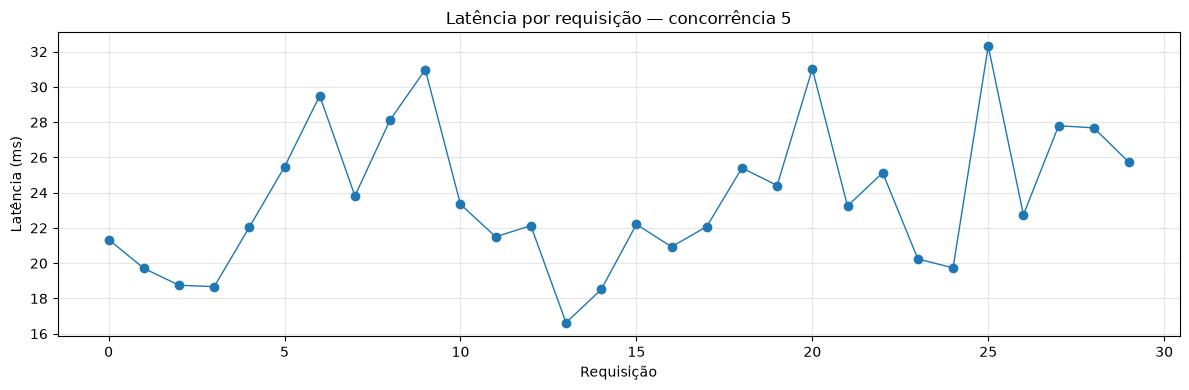

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(
    load_results["request_id"],
    load_results["latency_ms"],
    marker="o",
    linewidth=1,
)
plt.title(
    f"Latência por requisição — concorrência {CONCURRENCY}"
)
plt.xlabel("Requisição")
plt.ylabel("Latência (ms)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.2 Utilização de CPU durante a carga


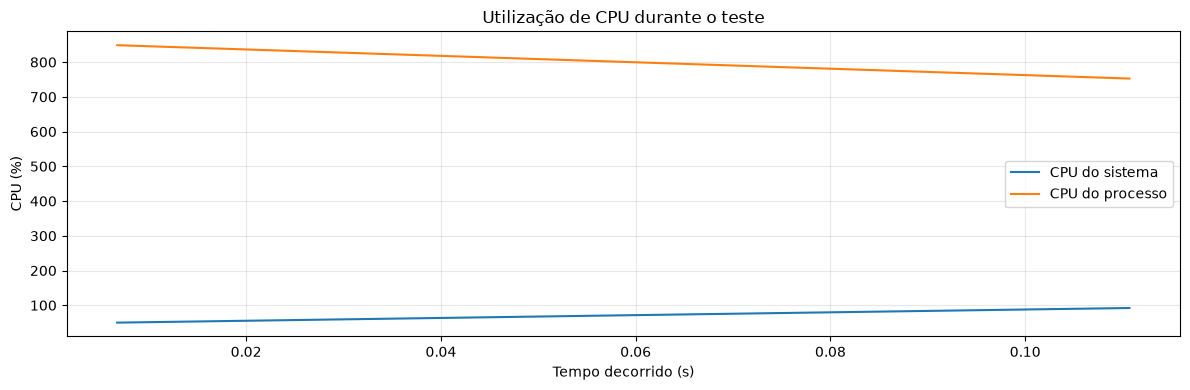

In [13]:
if not load_resources.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(
        load_resources["elapsed_seconds"],
        load_resources["system_cpu_percent"],
        label="CPU do sistema",
    )
    plt.plot(
        load_resources["elapsed_seconds"],
        load_resources["process_cpu_percent"],
        label="CPU do processo",
    )
    plt.title("Utilização de CPU durante o teste")
    plt.xlabel("Tempo decorrido (s)")
    plt.ylabel("CPU (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("O teste foi rápido demais para coletar amostras de CPU.")


### 7.3 Memória residente do processo


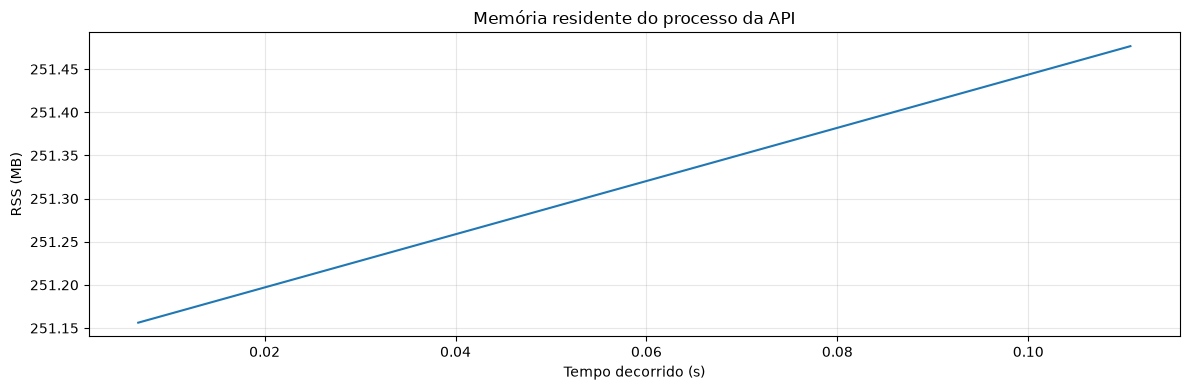

In [14]:
if not load_resources.empty:
    plt.figure(figsize=(12, 4))
    plt.plot(
        load_resources["elapsed_seconds"],
        load_resources["process_rss_mb"],
    )
    plt.title("Memória residente do processo da API")
    plt.xlabel("Tempo decorrido (s)")
    plt.ylabel("RSS (MB)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("O teste foi rápido demais para coletar amostras de memória.")


## 8. Comparação por nível de concorrência

Executamos o mesmo volume de chamadas com diferentes quantidades de requisições
simultâneas. O objetivo é observar:

- aumento ou redução do throughput;
- crescimento da latência p95;
- surgimento de erros;
- crescimento de CPU e memória.

Os resultados dependem do hardware, da versão do TensorFlow e do número de
threads disponíveis. Por isso devem ser medidos novamente no ambiente de
produção.


In [15]:
async def compare_concurrency(
    concurrency_levels=(1, 2, 5, 10),
    requests_per_level: int = 20,
):
    summaries = []

    for level in concurrency_levels:
        _, _, summary = await run_load_test(
            total_requests=requests_per_level,
            concurrency=int(level),
            horizon=1,
        )
        summaries.append(summary)

        # Pequena pausa para reduzir interferência entre os testes.
        await asyncio.sleep(0.25)

    return pd.DataFrame(summaries)


scalability_results = await compare_concurrency(
    concurrency_levels=(1, 2, 5, 10),
    requests_per_level=20,
)

columns_to_show = [
    "concurrency",
    "throughput_requests_per_second",
    "error_rate_percent",
    "latency_p50_ms",
    "latency_p95_ms",
    "latency_p99_ms",
    "max_process_cpu_percent",
    "max_process_rss_mb",
]

display(
    scalability_results[columns_to_show].round(2)
)


,concurrency,throughput_requests_per_second,error_rate_percent,latency_p50_ms,latency_p95_ms,latency_p99_ms,max_process_cpu_percent,max_process_rss_mb
0,1,147.24,0.0,6.28,10.23,11.89,673.0,263.66
1,2,179.59,0.0,10.09,18.46,19.37,1989.1,263.75
2,5,228.02,0.0,19.43,28.46,30.32,0.0,263.73
3,10,241.58,0.0,38.11,50.17,50.29,0.0,263.84


### 8.1 Throughput por concorrência


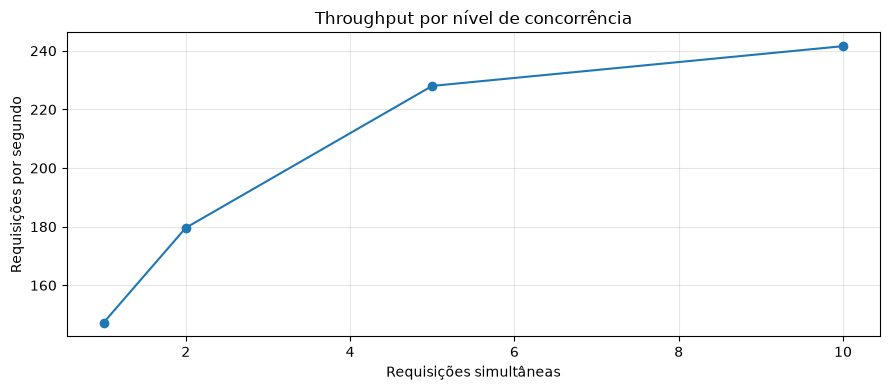

In [16]:
plt.figure(figsize=(9, 4))
plt.plot(
    scalability_results["concurrency"],
    scalability_results[
        "throughput_requests_per_second"
    ],
    marker="o",
)
plt.title("Throughput por nível de concorrência")
plt.xlabel("Requisições simultâneas")
plt.ylabel("Requisições por segundo")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 8.2 Latência p95 por concorrência


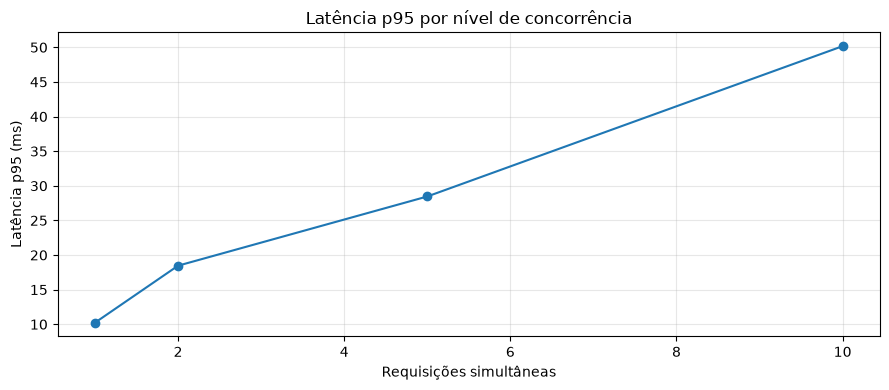

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(
    scalability_results["concurrency"],
    scalability_results["latency_p95_ms"],
    marker="o",
)
plt.title("Latência p95 por nível de concorrência")
plt.xlabel("Requisições simultâneas")
plt.ylabel("Latência p95 (ms)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. SLOs e critérios de aceite

Os limites abaixo são **valores iniciais do projeto**, não regras universais.
Eles devem ser ajustados de acordo com a infraestrutura, o volume esperado e o
contrato de serviço.

Neste exemplo avaliamos:

- latência p95 menor ou igual a 500 ms;
- taxa de erro menor ou igual a 1%;
- memória residente menor ou igual a 2 GB;
- CPU do processo menor ou igual a 95%.


In [18]:
SLO = {
    "latency_p95_ms": 500.0,
    "error_rate_percent": 1.0,
    "max_process_rss_mb": 2048.0,
    "max_process_cpu_percent": 95.0,
}

reference_row = scalability_results.iloc[
    (
        scalability_results["concurrency"]
        - CONCURRENCY
    ).abs().argmin()
]

slo_evaluation = pd.DataFrame(
    [
        {
            "indicador": "Latência p95",
            "valor_observado": reference_row[
                "latency_p95_ms"
            ],
            "limite": SLO["latency_p95_ms"],
            "unidade": "ms",
            "atende": (
                reference_row["latency_p95_ms"]
                <= SLO["latency_p95_ms"]
            ),
        },
        {
            "indicador": "Taxa de erro",
            "valor_observado": reference_row[
                "error_rate_percent"
            ],
            "limite": SLO["error_rate_percent"],
            "unidade": "%",
            "atende": (
                reference_row["error_rate_percent"]
                <= SLO["error_rate_percent"]
            ),
        },
        {
            "indicador": "Memória RSS",
            "valor_observado": reference_row[
                "max_process_rss_mb"
            ],
            "limite": SLO["max_process_rss_mb"],
            "unidade": "MB",
            "atende": (
                reference_row["max_process_rss_mb"]
                <= SLO["max_process_rss_mb"]
            ),
        },
        {
            "indicador": "CPU do processo",
            "valor_observado": reference_row[
                "max_process_cpu_percent"
            ],
            "limite": SLO[
                "max_process_cpu_percent"
            ],
            "unidade": "%",
            "atende": (
                reference_row[
                    "max_process_cpu_percent"
                ]
                <= SLO[
                    "max_process_cpu_percent"
                ]
            ),
        },
    ]
)

display(slo_evaluation.round(2))

if slo_evaluation["atende"].all():
    print("\n✅ Todos os SLOs avaliados foram atendidos.")
else:
    failed = slo_evaluation.loc[
        ~slo_evaluation["atende"],
        "indicador",
    ].tolist()
    print(
        "\n⚠️ SLOs não atendidos:",
        ", ".join(failed),
    )


,indicador,valor_observado,limite,unidade,atende
0,Latência p95,28.46,500.0,ms,True
1,Taxa de erro,0.00,1.0,%,True
2,Memória RSS,263.73,2048.0,MB,True
3,CPU do processo,0.00,95.0,%,True



✅ Todos os SLOs avaliados foram atendidos.


## 10. Arquivos de monitoramento para produção

A célula seguinte gera uma configuração mínima de:

- **Prometheus**, para coleta das métricas;
- **regras de alerta**, para latência, erros e memória;
- **Grafana**, com datasource e dashboard provisionados;
- **Docker Compose**, para iniciar Prometheus e Grafana.

A configuração considera que a API está disponível em
`host.docker.internal:8000`. Em Linux, o `extra_hosts` do Compose cria esse
mapeamento para o host.


In [19]:
MONITORING_DIR = Path("monitoring")
GRAFANA_PROVISIONING_DIR = (
    MONITORING_DIR / "grafana" / "provisioning"
)
GRAFANA_DASHBOARDS_DIR = (
    MONITORING_DIR / "grafana" / "dashboards"
)

def gravar_se_ausente(caminho, conteudo):
    """Não sobrescreve: monitoring/ é versionado e evoluiu além deste notebook."""
    if caminho.exists():
        print(f" = mantido (já existe): {caminho}")
        return
    caminho.write_text(conteudo, encoding="utf-8")
    print(f" + gerado: {caminho}")


(MONITORING_DIR).mkdir(
    parents=True,
    exist_ok=True,
)
(GRAFANA_PROVISIONING_DIR / "datasources").mkdir(
    parents=True,
    exist_ok=True,
)
(GRAFANA_PROVISIONING_DIR / "dashboards").mkdir(
    parents=True,
    exist_ok=True,
)
GRAFANA_DASHBOARDS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

prometheus_config = '''global:
  scrape_interval: 15s
  evaluation_interval: 15s

rule_files:
  - /etc/prometheus/alert_rules.yml

scrape_configs:
  - job_name: lstm_api
    metrics_path: /metrics/
    static_configs:
      - targets:
          - host.docker.internal:8000
'''

alert_rules = '''groups:
  - name: lstm_api_alerts
    rules:
      - alert: LSTMApiHighP95Latency
        expr: |
          histogram_quantile(
            0.95,
            sum(
              rate(
                lstm_api_http_request_duration_seconds_bucket{
                  path="/predict"
                }[5m]
              )
            ) by (le)
          ) > 0.5
        for: 5m
        labels:
          severity: warning
        annotations:
          summary: "Latência p95 elevada na API LSTM"
          description: "A latência p95 do /predict está acima de 500 ms."

      - alert: LSTMApiHighErrorRate
        expr: |
          (
            sum(
              rate(
                lstm_api_http_requests_total{
                  path="/predict",
                  status=~"5.."
                }[5m]
              )
            )
            /
            clamp_min(
              sum(
                rate(
                  lstm_api_http_requests_total{
                    path="/predict"
                  }[5m]
                )
              ),
              0.001
            )
          ) > 0.01
        for: 5m
        labels:
          severity: critical
        annotations:
          summary: "Taxa de erro elevada na API LSTM"
          description: "Mais de 1% das chamadas do /predict retornaram 5xx."

      - alert: LSTMApiHighMemory
        expr: |
          lstm_api_process_resident_memory_bytes > 2147483648
        for: 10m
        labels:
          severity: warning
        annotations:
          summary: "Uso elevado de memória na API LSTM"
          description: "O processo está utilizando mais de 2 GB de memória."
'''

docker_compose = '''services:
  prometheus:
    image: prom/prometheus:latest
    command:
      - --config.file=/etc/prometheus/prometheus.yml
    volumes:
      - ./prometheus.yml:/etc/prometheus/prometheus.yml:ro
      - ./alert_rules.yml:/etc/prometheus/alert_rules.yml:ro
    ports:
      - "9090:9090"
    extra_hosts:
      - "host.docker.internal:host-gateway"

  grafana:
    image: grafana/grafana:latest
    environment:
      GF_SECURITY_ADMIN_PASSWORD: ${GRAFANA_ADMIN_PASSWORD:-admin}
    volumes:
      - ./grafana/provisioning:/etc/grafana/provisioning:ro
      - ./grafana/dashboards:/var/lib/grafana/dashboards:ro
    ports:
      - "3000:3000"
    depends_on:
      - prometheus
'''

grafana_datasource = '''apiVersion: 1

datasources:
  - name: Prometheus
    type: prometheus
    access: proxy
    url: http://prometheus:9090
    isDefault: true
    editable: false
'''

grafana_dashboard_provider = '''apiVersion: 1

providers:
  - name: Tech Challenge
    orgId: 1
    folder: Tech Challenge
    type: file
    disableDeletion: false
    updateIntervalSeconds: 10
    options:
      path: /var/lib/grafana/dashboards
'''

dashboard = {
    "annotations": {
        "list": []
    },
    "editable": True,
    "panels": [
        {
            "type": "timeseries",
            "title": "Latência p95 do /predict",
            "gridPos": {
                "h": 8,
                "w": 12,
                "x": 0,
                "y": 0,
            },
            "targets": [
                {
                    "expr": (
                        "histogram_quantile(0.95, "
                        "sum(rate("
                        "lstm_api_http_request_duration_seconds_bucket"
                        "{path=\"/predict\"}[5m])) by (le))"
                    ),
                    "legendFormat": "p95",
                }
            ],
            "fieldConfig": {
                "defaults": {
                    "unit": "s",
                },
                "overrides": [],
            },
        },
        {
            "type": "timeseries",
            "title": "Requisições por segundo",
            "gridPos": {
                "h": 8,
                "w": 12,
                "x": 12,
                "y": 0,
            },
            "targets": [
                {
                    "expr": (
                        "sum(rate("
                        "lstm_api_http_requests_total"
                        "{path=\"/predict\"}[1m]))"
                    ),
                    "legendFormat": "RPS",
                }
            ],
        },
        {
            "type": "timeseries",
            "title": "Taxa de erro 5xx",
            "gridPos": {
                "h": 8,
                "w": 12,
                "x": 0,
                "y": 8,
            },
            "targets": [
                {
                    "expr": (
                        "100 * sum(rate("
                        "lstm_api_http_requests_total"
                        "{path=\"/predict\",status=~\"5..\"}[5m])) "
                        "/ clamp_min(sum(rate("
                        "lstm_api_http_requests_total"
                        "{path=\"/predict\"}[5m])), 0.001)"
                    ),
                    "legendFormat": "Erros",
                }
            ],
            "fieldConfig": {
                "defaults": {
                    "unit": "percent",
                },
                "overrides": [],
            },
        },
        {
            "type": "timeseries",
            "title": "Memória do processo",
            "gridPos": {
                "h": 8,
                "w": 12,
                "x": 12,
                "y": 8,
            },
            "targets": [
                {
                    "expr": (
                        "lstm_api_process_resident_memory_bytes"
                    ),
                    "legendFormat": "RSS",
                }
            ],
            "fieldConfig": {
                "defaults": {
                    "unit": "bytes",
                },
                "overrides": [],
            },
        },
        {
            "type": "timeseries",
            "title": "CPU do processo",
            "gridPos": {
                "h": 8,
                "w": 12,
                "x": 0,
                "y": 16,
            },
            "targets": [
                {
                    "expr": (
                        "lstm_api_process_cpu_percent"
                    ),
                    "legendFormat": "CPU",
                }
            ],
            "fieldConfig": {
                "defaults": {
                    "unit": "percent",
                },
                "overrides": [],
            },
        },
        {
            "type": "timeseries",
            "title": "Latência p95 da inferência",
            "gridPos": {
                "h": 8,
                "w": 12,
                "x": 12,
                "y": 16,
            },
            "targets": [
                {
                    "expr": (
                        "histogram_quantile(0.95, "
                        "sum(rate("
                        "lstm_model_inference_duration_seconds_bucket"
                        "[5m])) by (le))"
                    ),
                    "legendFormat": "p95 inferência",
                }
            ],
            "fieldConfig": {
                "defaults": {
                    "unit": "s",
                },
                "overrides": [],
            },
        },
        {
            "type": "timeseries",
            "title": "Erro percentual p95 do modelo",
            "gridPos": {
                "h": 8,
                "w": 12,
                "x": 0,
                "y": 24,
            },
            "targets": [
                {
                    "expr": (
                        "histogram_quantile(0.95, "
                        "sum(rate("
                        "lstm_model_absolute_percentage_error_bucket"
                        "[1h])) by (le))"
                    ),
                    "legendFormat": "APE p95",
                }
            ],
            "fieldConfig": {
                "defaults": {
                    "unit": "percent",
                },
                "overrides": [],
            },
        },
        {
            "type": "timeseries",
            "title": "Previsões acumuladas",
            "gridPos": {
                "h": 8,
                "w": 12,
                "x": 12,
                "y": 24,
            },
            "targets": [
                {
                    "expr": (
                        "sum(lstm_model_predictions_total)"
                    ),
                    "legendFormat": "Previsões",
                }
            ],
        },
    ],
    "refresh": "10s",
    "schemaVersion": 39,
    "tags": [
        "lstm",
        "fastapi",
        "tech-challenge",
    ],
    "templating": {
        "list": []
    },
    "time": {
        "from": "now-1h",
        "to": "now",
    },
    "timezone": "browser",
    "title": "Tech Challenge — API LSTM",
    "uid": "tech-challenge-lstm",
    "version": 1,
}

gravar_se_ausente(MONITORING_DIR / "prometheus.yml", prometheus_config)
gravar_se_ausente(MONITORING_DIR / "alert_rules.yml", alert_rules)
gravar_se_ausente(
    MONITORING_DIR / "docker-compose.monitoring.yml", docker_compose
)
gravar_se_ausente(
    GRAFANA_PROVISIONING_DIR / "datasources" / "prometheus.yml",
    grafana_datasource,
)
gravar_se_ausente(
    GRAFANA_PROVISIONING_DIR / "dashboards" / "dashboard.yml",
    grafana_dashboard_provider,
)
gravar_se_ausente(
    GRAFANA_DASHBOARDS_DIR / "lstm_api.json",
    json.dumps(dashboard, indent=2, ensure_ascii=False),
)

print("Arquivos gerados:")
for path in sorted(
    MONITORING_DIR.rglob("*")
):
    if path.is_file():
        print(" -", path)


 = mantido (já existe): monitoring/prometheus.yml
 = mantido (já existe): monitoring/alert_rules.yml
 = mantido (já existe): monitoring/docker-compose.monitoring.yml
 = mantido (já existe): monitoring/grafana/provisioning/datasources/prometheus.yml
 = mantido (já existe): monitoring/grafana/provisioning/dashboards/dashboard.yml
 = mantido (já existe): monitoring/grafana/dashboards/lstm_api.json
Arquivos gerados:
 - monitoring/alert_rules.yml
 - monitoring/docker-compose.monitoring.yml
 - monitoring/grafana/dashboards/lstm_api.json
 - monitoring/grafana/provisioning/dashboards/dashboard.yml
 - monitoring/grafana/provisioning/datasources/prometheus.yml
 - monitoring/prometheus.yml


## 11. Execução local com Prometheus e Grafana

Para permitir que o Prometheus colete as métricas, a API precisa estar ouvindo
em uma porta real. A célula abaixo é opcional e bloqueia o notebook enquanto o
servidor estiver ativo.

Depois de iniciar a API, abra outro terminal na pasta `monitoring/` e execute:

```bash
docker compose -f docker-compose.monitoring.yml up -d
```

Interfaces:

- API: `http://localhost:8000`
- documentação Swagger: `http://localhost:8000/docs`
- métricas: `http://localhost:8000/metrics/`
- Prometheus: `http://localhost:9090`
- Grafana: `http://localhost:3000`

Em um deploy definitivo, mova a definição da aplicação para um módulo Python e
execute o Uvicorn a partir desse módulo.


In [20]:
# Execute somente quando quiser manter a API disponível em localhost:8000.
# A célula ficará ocupada até o servidor ser interrompido.
#
# import uvicorn
# uvicorn.run(app, host="0.0.0.0", port=8000)


## 12. Estratégia de escalabilidade

Os resultados do benchmark devem orientar a configuração do deploy.

Boas práticas aplicáveis a esta API:

1. **Carregar o modelo apenas uma vez por processo.** Cada worker mantém sua
   própria cópia do TensorFlow e do modelo em memória.
2. **Testar a quantidade de workers.** Mais workers podem aumentar o throughput,
   mas também multiplicam o consumo de RAM.
3. **Escalar horizontalmente.** Quando uma instância não atende aos SLOs, use
   réplicas atrás de um balanceador de carga.
4. **Separar liveness e readiness.** O `/health` indica saúde geral, enquanto o
   `/ready` confirma que modelo e scaler foram carregados.
5. **Aplicar limites e requests de CPU/memória.** Isso evita competição
   imprevisível entre serviços.
6. **Acompanhar erro preditivo.** O endpoint `/feedback` permite medir a qualidade
   quando o valor real se torna disponível.
7. **Evitar labels de alta cardinalidade.** Não use identificadores de usuário ou
   preços como labels do Prometheus.
8. **Reavaliar o modelo periodicamente.** Mudanças na distribuição dos retornos
   podem exigir novo treinamento.


## Pronto ✅

O ponto 5 foi atendido com:

- instrumentação Prometheus na API;
- métricas de latência HTTP e inferência;
- contagem de requisições e erros;
- acompanhamento de CPU e memória;
- registro de erro preditivo por feedback;
- benchmark concorrente com p50, p95, p99 e throughput;
- avaliação de SLOs;
- configuração de alertas;
- dashboard Grafana provisionado;
- orientações para escalabilidade horizontal e ajuste de workers.

Os arquivos de observabilidade são gerados na pasta `monitoring/` quando a
respectiva célula é executada.
